In [3]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt

load_dotenv()

engine = create_engine(os.environ['DATABASE'])

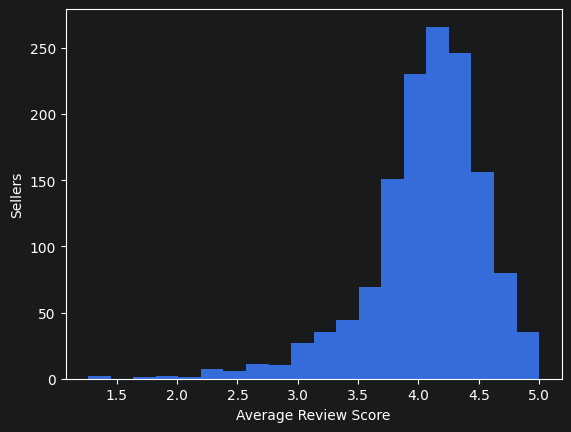

In [4]:
review_scores = pd.read_sql("SELECT raw.order_items.seller_id, AVG(raw.reviews.review_score) AS average_review_score "
                            "FROM raw.order_items "
                            "JOIN raw.reviews ON raw.order_items.order_id = raw.reviews.order_id "
                            "GROUP BY raw.order_items.seller_id "
                            "HAVING COUNT(raw.order_items.order_id) >= 10 "
                            "ORDER BY average_review_score DESC;",
                            engine)

review_scores['average_review_score'].plot(kind='hist', bins=20)
plt.xlabel('Average Review Score')
plt.ylabel('Sellers')
plt.show()
